In [1]:
#!pip install git+https://github.com/mrayson/iwaves.git

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from iwaves.utils.imodes import IWaveModes
from iwaves.utils.density import FitDensity

from glob import glob

import cmocean as cm

In [3]:
plt.rcParams['font.size']=14
plt.rcParams['axes.labelsize']='large'
plt.rcParams['pcolor.shading']='auto'

In [4]:
ls /home/jupyter-ubuntu/data/SWOT_Cruise/FV02/stacked_moorings_tp/

'[BB23]_[BB23_REC]_[N280]_[multi(27)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(27)_instrument_serial_number]_[no_outfile_append].nc'
'[BB23]_[BB23_REC]_[S245]_[multi(35)_nominal_instrument_height_asb]_[multi(2)_instrument_model]_[multi(35)_instrument_serial_number]_[no_outfile_append].nc'
'[BB23]_[BB23_REC]_[S245]_[multi(36)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(36)_instrument_serial_number]_[no_outfile_append].nc'
'[BB23]_[BB23_REC]_[S245]_[multi(37)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(37)_instrument_serial_number]_[no_outfile_append].nc'
'[BB23]_[BB23_REC]_[W310]_[multi(26)_nominal_instrument_height_asb]_[multi(4)_instrument_model]_[multi(26)_instrument_serial_number]_[no_outfile_append].nc'
'[BB23]_[BB23_REC]_[W310]_[multi(27)_nominal_instrument_height_asb]_[multi(5)_instrument_model]_[multi(27)_instrument_serial_number]_[no_outfile_append].nc'
 figures/


In [48]:
# sitename='N280'
# ncfile ='[BB23]_[BB23_REC]_[N280]_[multi(27)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(27)_instrument_serial_number]_[no_outfile_append].nc'
# z_bot = -280

# sitename='W310'
# ncfile = '[BB23]_[BB23_REC]_[W310]_[multi(27)_nominal_instrument_height_asb]_[multi(5)_instrument_model]_[multi(27)_instrument_serial_number]_[no_outfile_append].nc'
# z_bot = -314

sitename='S245'
ncfile = '[BB23]_[BB23_REC]_[S245]_[multi(35)_nominal_instrument_height_asb]_[multi(2)_instrument_model]_[multi(35)_instrument_serial_number]_[no_outfile_append].nc'
z_bot = -254

## ds = xr.open_dataset('/home/jupyter-mrayson/data/SWOT_Cruise/FV02/stacked_moorings_tp/[BB23]_[BB23_REC]_[S245]_[multi(36)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(36)_instrument_serial_number]_[no_outfile_append].nc')
## ds = xr.open_dataset('/home/jupyter-mrayson/data/SWOT_Cruise/FV02/stacked_moorings_tp/[BB23]_[BB23_REC]_[S245]_[multi(37)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(37)_instrument_serial_number]_[no_outfile_append].nc')

t1 = '2023-04-23 00:00:00'
t2 = '2023-05-31 00:00:00'

# t1 = '2023-04-26 00:00:00'
# t2 = '2023-04-29 00:00:00'

# t1 = '2023-05-07 00:00:00'
# t2 = '2023-05-10 00:00:00'

####
ds_ = xr.open_dataset('/home/jupyter-ubuntu/data/SWOT_Cruise/FV02/stacked_moorings_tp/'+ncfile)                     
ds = ds_.sel(time=slice(t1,t2))
ds

<xarray.Dataset> Size: 31MB
Dimensions:      (z_nom: 35, time: 54720)
Coordinates:
  * z_nom        (z_nom) float64 280B -244.4 -239.4 -231.8 ... -19.12 -12.62
  * time         (time) datetime64[ns] 438kB 2023-04-23T00:00:59.028800 ... 2...
    lat_nom      float64 8B ...
    lon_nom      float64 8B ...
Data variables:
    Temperature  (z_nom, time) float64 15MB ...
    Pressure     (z_nom, time) float64 15MB ...
    source       (z_nom) <U13 2kB ...
Attributes: (12/35)
    title:                           Mooring made by stacking multipe files
    institution:                     The University of Western Australia
    institution_division:            Ocean Dynamics
    source:                          D:\BB23(All)\data\moored_instrument_data...
    project:                         BB23
    history:                         
    ...                              ...
    nominal_instrument_height_asb:   0.6;5.625;13.177;19.177;22.177;25.177;28...
    nominal_instrument_orientation:  
    timezone:                        UTC
    process_level:                   2
    is_profile_data:                 0
    pimos_nickname:                  stacked_moorings_tp

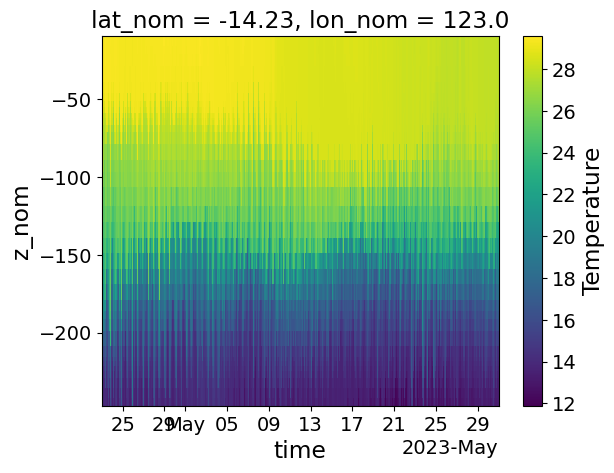

In [49]:
T_fill = ds['Temperature'].interpolate_na('z_nom', method='linear',fill_value='extrapolate')

T_fill.plot()

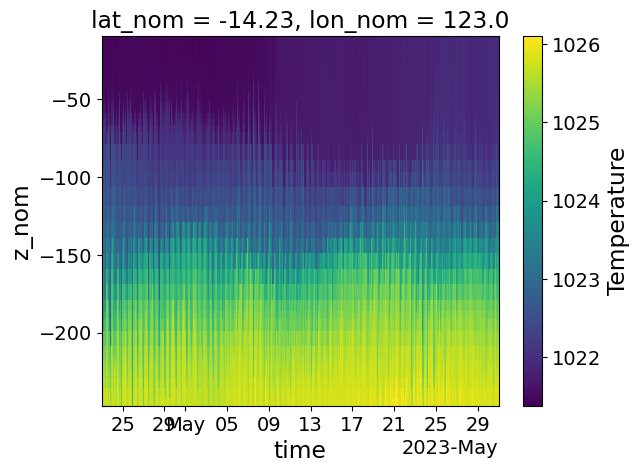

In [50]:
import gsw

rho = gsw.pot_rho_t_exact( 34.5, T_fill,-ds['z_nom'], 0)

rho.plot()

In [51]:
iw = IWaveModes(rho.mean('time').values, rho.z_nom.values)

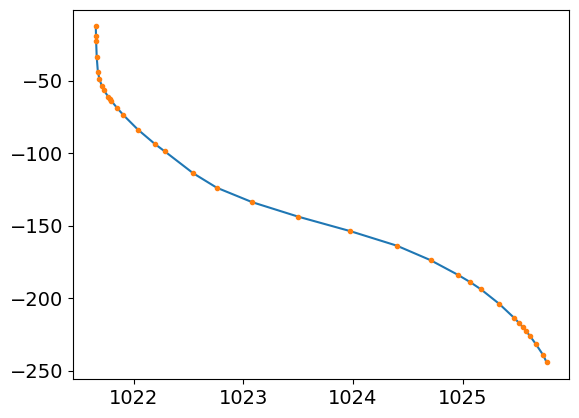

In [52]:
plt.plot(iw.rho, iw.z)
plt.plot(rho.mean('time').values, rho['z_nom'].values ,'.')

(-254.0, 0.0)

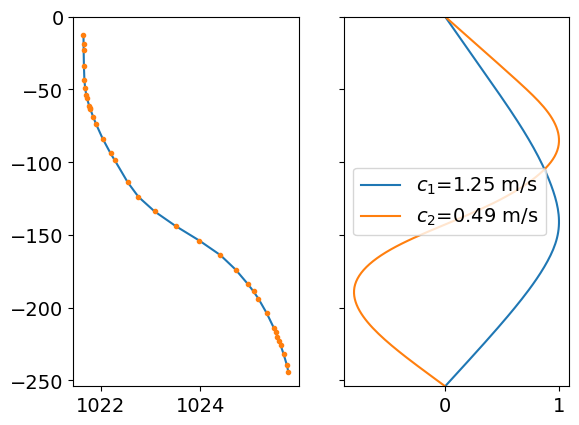

In [53]:
dz = 2
phi1, c1, _, zm = iw(z_bot, dz, 0)
phi2, c2, _, zm = iw(z_bot, dz, 1)

ax=plt.subplot(121)
plt.plot(iw.rho, iw.z)
plt.plot(rho.mean('time').values, rho['z_nom'].values ,'.')
ax.set_ylim(z_bot,0)
ax2 = plt.subplot(122)
plt.plot(phi1, zm)
plt.plot(phi2, zm)
plt.legend((f'$c_1$={c1:3.2f} m/s',
            f'$c_2$={c2:3.2f} m/s'))
ax2.set_yticklabels([])
ax2.set_ylim(z_bot,0)


# Kelly 2016 free-surface modes

Used copilot to convert Sam Kelly's matlab code:)

In [54]:
import numpy as np
from scipy.optimize import brentq, newton

def modes_fs(dz, N2, Nm, FS_flag=1, Nm0=None):
    """
    Compute vertical modes for arbitrary stratification with (or without) a free surface
    using a spectral method with constant-N basis functions. Free-surface dispersion
    roots are found with SciPy (brentq/newton).

    Parameters
    ----------
    dz : float
        Vertical spacing (must be uniform).
    N2 : array_like, shape (Nz,)
        Stratification (buoyancy frequency squared).
    Nm : int
        Number of modes to extract.
    FS_flag : int, optional (default=1)
        1 => free-surface boundary conditions;
        0 => rigid-lid boundary conditions.
    Nm0 : int or None, optional
        Number of basis modes to use for the spectral method (Nm0 >= 2*Nm recommended).
        If None, defaults to max(64, 2*Nm).

    Returns
    -------
    PHI_p : ndarray, shape (Nz, Nm)
        Pressure/velocity structure eigenfunctions (scaled consistently with PHI_w).
    C : ndarray, shape (Nm,)
        Eigenspeeds (phase speeds).
    PHI_w : ndarray, shape (Nz, Nm)
        Vertical velocity structure eigenfunctions, with max(|PHI_w[:,i]|) == 1 for each mode i.
    """
    # --- Inputs & basic quantities ---
    N2 = np.asarray(N2, dtype=float).ravel()
    Nz = N2.size
    g = 9.81
    z = np.arange(1, Nz + 1, dtype=float) * dz - dz / 2.0  # centered in grid cells
    H = dz * Nz
    N20 = float(np.mean(N2))

    if Nm0 is None:
        Nm0 = max(64, 2 * Nm)

    # --- Define RL "alpha" guesses and adjust counts depending on FS_flag ---
    if FS_flag:
        alpha_RL = np.concatenate(([0.0], np.pi * np.arange(1, Nm0)))
    else:
        Nm = Nm - 1            # surface mode will be added later
        Nm0 = Nm0 - 1
        alpha_RL = np.pi * np.arange(1, Nm0 + 1)

    # --- Free-surface dispersion f(a) = a sin a - beta cos a ---
    beta = (N20 * H) / g

    def fs_func(a):
        return a * np.sin(a) - beta * np.cos(a)

    def fs_dfunc(a):
        return np.sin(a) + a * np.cos(a) + beta * np.sin(a)

    def find_fs_root(guess, width=np.pi/4, max_expand=20):
        """
        Prefer a bracketing solve (brentq) around [guess-width, guess+width],
        expand if needed; if no sign change is found, fall back to Newton.
        """
        L, R = guess - width, guess + width
        fL, fR = fs_func(L), fs_func(R)
        expand_count = 0
        while fL * fR > 0 and expand_count < max_expand:
            L -= width
            R += width
            fL, fR = fs_func(L), fs_func(R)
            expand_count += 1

        if fL * fR < 0:
            try:
                return brentq(fs_func, L, R, xtol=1e-12, rtol=1e-10, maxiter=200)
            except Exception:
                pass

        # Fallback: Newton with derivative, then without
        try:
            return newton(fs_func, guess, fprime=fs_dfunc, tol=1e-12, maxiter=200)
        except Exception:
            return newton(fs_func, guess, tol=1e-12, maxiter=200)

    # --- Build constant-N basis ---
    phi_w = np.zeros((Nz, Nm0), dtype=float)
    phi_p = np.zeros((Nz, Nm0), dtype=float)
    phi_w_surf = np.zeros((Nm0,), dtype=float)
    alpha0 = np.array(alpha_RL, dtype=float)

    if FS_flag:
        for i in range(Nm0):
            guess = alpha_RL[i]
            width = np.pi / 2 if i == 0 else np.pi / 4
            alpha0[i] = find_fs_root(guess=guess, width=width)

    zh = 1.0 - z / H
    for i in range(Nm0):
        a = alpha0[i]

        # Basis vertical velocity and pressure/velocity structures
        phi_w[:, i] = np.sin(a * zh)
        phi_w_surf[i] = np.sin(a)
        phi_p[:, i] = -(a / H) * np.cos(a * zh)

        # Normalize constant-N basis modes (as per original MATLAB)
        c20 = (N20 * H * H) / (a * a) if a != 0.0 else np.inf
        num = np.mean((phi_w[:, i] ** 2) * N2) + (g / H) * (phi_w_surf[i] ** 2)
        A = np.sqrt(abs(num / c20)) if np.isfinite(c20) else 1.0
        if A == 0:
            A = 1.0
        phi_w[:, i] /= A
        phi_w_surf[i] /= A

        A2 = np.sqrt(np.mean(phi_p[:, i] ** 2))
        if A2 == 0:
            A2 = 1.0
        phi_p[:, i] /= A2

    # --- Coupling matrix for variable stratification ---
    M = (phi_w.T @ (N2[:, None] * phi_w)) / Nz
    A = M + (g / H) * np.outer(phi_w_surf, phi_w_surf)

    # --- Symmetric eigenproblem ---
    c2, X = np.linalg.eigh(A)
    c2 = np.maximum(c2, 0.0)
    C_all = np.sqrt(c2)
    idx = np.argsort(C_all)[::-1]  # descending
    C_all = C_all[idx]
    X = X[:, idx]

    # Retain Nm fastest modes
    C = C_all[:Nm]
    X = X[:, :Nm]

    # --- Reconstruct ---
    PHI_w = phi_w @ X
    PHI_w_surf_rec = phi_w_surf @ X  # (Nm,)
    PHI_p = phi_p @ X

    # --- Normalize as in MATLAB (energy-weighted for w, L2 for p) ---
    numer = (np.mean((PHI_w ** 2) * N2[:, None], axis=0) + (g / H) * (PHI_w_surf_rec ** 2))
    denom = C * C
    Aw = np.sqrt(np.divide(numer, denom, out=np.ones_like(numer), where=denom > 0))
    Aw[Aw == 0] = np.inf
    PHI_w = PHI_w / Aw
    PHI_p = PHI_p / Aw  # keep PHI_p consistent with PHI_w scaling so far

    # L2-normalize p modes (as in MATLAB)
    Ap = np.sqrt(np.mean(PHI_p ** 2, axis=0))
    Ap[Ap == 0] = np.inf
    PHI_p = PHI_p / Ap

    # Ensure pressure positive at surface
    flip = PHI_p[0, :] < 0
    PHI_p[:, flip] *= -1.0
    PHI_w[:, flip] *= -1.0

    # --- Final request: make max(|PHI_w[:, i]|) == 1 for each mode ---
    #maxabs_w = np.max(np.abs(PHI_w), axis=0)
    #maxabs_w[maxabs_w == 0] = 1.0  # avoid division by zero
    #PHI_w = PHI_w / maxabs_w
    #PHI_p = PHI_p / maxabs_w  # scale PHI_p consistently with PHI_w

    # --- Add surface mode for rigid-lid case (unchanged) ---
    if FS_flag == 0:
        C = np.concatenate(([np.sqrt(g * H)], C))
        PHI_w = np.column_stack((np.zeros((Nz, 1)), PHI_w))
        PHI_p = np.column_stack((np.ones((Nz, 1)), PHI_p))

    return PHI_p, C, PHI_w

In [55]:
#modes_fs(dz, N2, Nm
phi_z, cn , phi_fs = modes_fs(iw.dz, iw.N2, 8)
cn

array([50.14748106,  1.05030392,  0.49651364,  0.33070391,  0.23883952,
        0.18682471,  0.15631254,  0.1331371 ])

Key results:
- Mode 1 and 2 eigenspeeds are 1.20 and 0.61 m/s at W310
- Mode 1 and 2 eigenspeeds are 1.05 and 0.50 m/s at S245

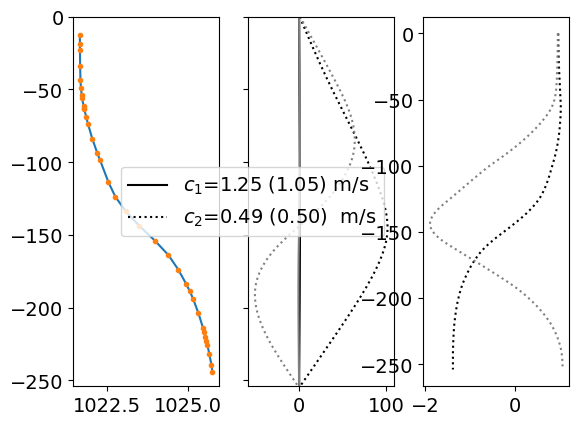

In [56]:
ax=plt.subplot(131)
plt.plot(iw.rho, iw.z)
plt.plot(rho.mean('time').values, rho['z_nom'].values ,'.')
ax.set_ylim(z_bot,0)

ax2 = plt.subplot(132)
plt.plot(phi1, zm,'k')
plt.plot(phi_fs[:,1], zm, 'k:')
plt.plot(phi2, zm,'0.5')
plt.plot(phi_fs[:,2], zm, ':', c='0.5')

plt.legend((f'$c_1$={c1:3.2f} ({cn[1]:3.2f}) m/s',
            f'$c_2$={c2:3.2f} ({cn[2]:3.2f})  m/s'))
ax2.set_yticklabels([])
ax2.set_ylim(z_bot,0)

ax2 = plt.subplot(133)
plt.plot(phi_z[:,1], zm, 'k:')
plt.plot(phi_z[:,2], zm, ':', c='0.5')


# Zaron and Ray, 2024

Key result is the ratio of bottom to surface pressure eigenmode

$$
\frac{\phi_z(-H)}{\phi_z(0)} 
$$

A negative ratio of $-X$, means steric height will overestimate the SSH by $X$ \%, or that bottom pressure cancels out steric height contributions to sea level. A positive ratio of $X$, means steric height will underestimate the SSH by $X$ \%, or that bottom pressure will be the main contributer to sea level. If the ratio is zero steric height will capture sea level.

*Text for discussion*
The issue of using steric height as a proxy for internal tide induced sea surface height (baroclinic sea level) has been raised by Zaron and Ray (2024). They use linear internal wave theory (e.g., Gill, 1982), with the usual simplifying assumptions (hydrostatic, flat-bottom, periodic waves), to show that the ratio of bottom to surface pressure eigenmode
$
R=\phi_z(-H)/\phi_z(0)
$
gives a measure of the steric height contribution error. A negative ratio of $R$, means steric height will overestimate the SSH by $R$ \%, or that bottom pressure cancels out steric height contributions to sea level. A positive ratio of $R$, means steric height will underestimate the SSH by $R$ \%, or that bottom pressure will be the main contributer to sea level. If the ratio is zero, steric height will capture sea level.

Our observations revealed that using the steric height as a proxy for sea surface height would over-estimate the total sea level for mode-1 NLIW and under-estimate it for mode-2 NLIW. For example, the mode-1 NLIW on April 28 at S245 had a peak-to-trough steric height perturbation of 14 cm (Fig 1c) whereas the hydrostatic perturbation was 8 cm (Fig 3b). Conversely, the mode-2 NLIW on May 7 at W310 had a peak-to-trough steric height perturbation of about 4 cm (Fig 2c) whereas the hydrostatic perturbation was 8 cm (Fig 3b). In general, the bottom pressure contribution was larger than the steric height contribution to sea level at W310 during mode-2 NLIW.

Zaron and Ray's argument for linear internal tides help explain this observation, at least approximately. We computed the vertical pressure eigenmodes at each mooring using the deployment time-averaged density for the buoyancy frequency profile, and using the normal mode equation with a linear free-surface (Kelly, 2016). The ratio of bottom to surface pressure eigenmode for mode-1 revealed that steric height would overestimate to sea surface height by 102 \% and 69 \% at W310 and S245, respectively. However, for mode-2 internal waves, the steric height would underestimate total sea surface height by 80 \% and 90 \% at W310 and S245, respectively. Zaron and Ray's general statement that steric height will overpredict baroclinic sea surface height for odd modes (mode-1) and underpredict for even modes seems to hold for NLIW too.  



In [57]:
phi_z[0,1]/phi_z[-1,1]

-0.6913267805761707

- The mode-1 steric height will overestimate total height by 102 % at W310.
- The mode-1 steric height will overestimate total height by 69 % at S245.

In [58]:
phi_z[0,2]/phi_z[-1,2], sitename

(0.8990269293059491, 'S245')

- The mode-2 steric height will under-estimate the total height by 80 % at W310.
- The mode-2 steric height will under-estimate the total height by 90 % at S245.

## Isopycnal displacement / wave amplitude

From Qiu et al 

$$
\eta_0 = - \frac{a g H}
{\displaystyle \int_{-H}^{0}
\left[
\int_{z}^{0} N^2(z')\, \Phi(z') \, \mathrm{d}z'
\right]
\mathrm{d}z }
$$

$\eta_0$ is the isopycnal displacement amplitude,
$a$ is the free-surface amplitude



In [59]:
z = iw.Z
N2 = iw.N2
phi = phi2

cff1 = np.cumsum(N2*phi*dz)

cff2 = np.sum(cff1*dz)

eta0 = 1

a = - eta0 *(9.81*z_bot) / cff2
a, cff2

(2852.4489695998222, 0.8735441112377107)

# Chek the salinity for sanity

In [117]:
sfiles = glob('/home/jupyter-ubuntu/data/SWOT_Cruise/FV01/SBE37/*.nc')

sfiles

['/home/jupyter-ubuntu/data/SWOT_Cruise/FV01/SBE37/[BB23]_[BB23_REC]_[W310]_[16995]_[SBE37 CTD]_[12738]_[no_outfile_append].nc',
 '/home/jupyter-ubuntu/data/SWOT_Cruise/FV01/SBE37/[BB23]_[BB23_REC]_[W310]_[23252]_[SBE37 CTD]_[12739]_[no_outfile_append].nc',
 '/home/jupyter-ubuntu/data/SWOT_Cruise/FV01/SBE37/[BB23]_[BB23_REC]_[W310]_[9495]_[SBE37 CTD]_[11063]_[no_outfile_append].nc',
 '/home/jupyter-ubuntu/data/SWOT_Cruise/FV01/SBE37/[BB23]_[BB23_REC]_[W310]_[28252]_[SBE37 CTD]_[9276]_[no_outfile_append].nc']

In [118]:
ds_s = [xr.open_dataset(sf, engine='h5netcdf').sel(time=slice(t1,t2)) for sf in sfiles]
ds_s[0]

<xarray.Dataset> Size: 10MB
Dimensions:          (time: 176560)
Coordinates:
  * time             (time) datetime64[ns] 1MB 2023-04-23T00:00:01 ... 2023-0...
    lat_nom          float64 8B ...
    lon_nom          float64 8B ...
    z_nom            float64 8B ...
Data variables:
    Conductivity     (time) float64 1MB ...
    Temperature      (time) float64 1MB ...
    Pressure         (time) float64 1MB ...
    qc_Temperature   (time) float64 1MB ...
    qc_Pressure      (time) float64 1MB ...
    qc_Conductivity  (time) float64 1MB ...
Attributes: (12/35)
    title:                           Measured data from a Seabird Data Logger
    institution:                     The University of Western Australia
    institution_division:            Ocean Dynamics
    source:                          Seabird Data Logger
    project:                         BB23
    history:                         
    ...                              ...
    nominal_instrument_height_asb:   169.956
    nominal_instrument_orientation:  
    timezone:                        UTC
    process_level:                   1
    is_profile_data:                 0
    pimos_nickname:                  SBE37

In [119]:
salt = [gsw.SP_from_C(dd['Conductivity']/1000, dd['Temperature'], dd['Pressure']) for dd in ds_s]
salt[0]

<xarray.DataArray 'Conductivity' (time: 176560)> Size: 1MB
array([34.41077685, 34.40946565, 34.41040736, ..., 34.4271603 ,
       34.42769279, 34.4262579 ])
Coordinates:
  * time     (time) datetime64[ns] 1MB 2023-04-23T00:00:01 ... 2023-05-26T14:...
    lat_nom  float64 8B -14.14
    lon_nom  float64 8B 122.8
    z_nom    float64 8B -140.0

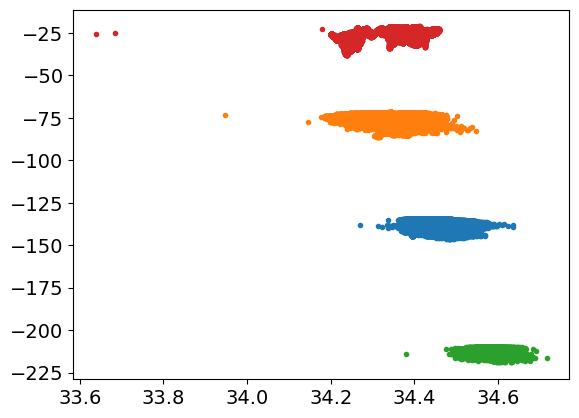

In [120]:
for ss, dd in zip(salt, ds_s):
    plt.plot(ss.values, -dd['Pressure'].values,'.')

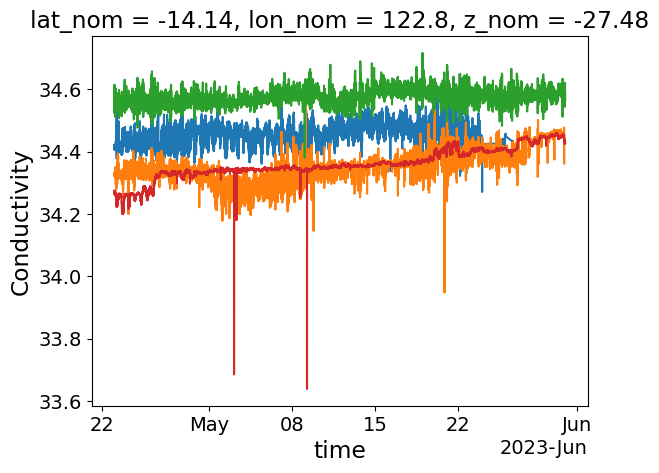

In [121]:
for ss, dd in zip(salt, ds_s):
    ss.plot()